In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data.csv')

print("Number of rows: ",len(df))
print("Number of columns: ",len(df.columns))

Number of rows:  7500
Number of columns:  16


In [3]:
df.head()

,Location,Area,Baths,Beds,Dining Room,Laundry Room,Store Rooms,Kitchens,Drawing Room,Gym,Powder Room,Steam Room,No additional rooms,Prayer Rooms,Lounge or Sitting Room,Price
0,"Bahria Town, Lahore, Punjab",10 Marla,-,-,0,0,0,0,0,0,0,0,1,0,0,PKR3.5 Crore
1,"Al Rehman Garden, Lahore, Punjab",4 Marla,4,3,1,1,1,2,1,0,0,0,0,1,0,PKR1.32 Crore
2,"Central Park Housing Scheme, Lahore, Punjab",5 Marla,4,3,0,0,0,0,0,0,0,0,1,0,0,PKR1.74 Crore
3,"DHA Defence, Lahore, Punjab",1 Kanal,6,5,0,0,0,0,0,0,0,0,0,0,0,PKR10.3 Crore
4,"DHA Defence, Lahore, Punjab",1 Kanal,6,5,1,1,2,2,1,0,1,1,0,1,1,PKR8.25 Crore


In [4]:
print("Column names")
for col in df.columns:
  print("-", col)

Column names
- Location
- Area
- Baths
- Beds
- Dining Room
- Laundry Room
- Store Rooms
- Kitchens
- Drawing Room
- Gym
- Powder Room
- Steam Room
- No additional rooms
- Prayer Rooms
- Lounge or Sitting Room
- Price


In [5]:
print("Missing values in column: ")
print(df.isnull().sum())

Missing values in column: 
Location                  0
Area                      0
Baths                     0
Beds                      0
Dining Room               0
Laundry Room              0
Store Rooms               0
Kitchens                  0
Drawing Room              0
Gym                       0
Powder Room               0
Steam Room                0
No additional rooms       0
Prayer Rooms              0
Lounge or Sitting Room    0
Price                     0
dtype: int64


In [6]:
def convertArea(text):
  text=str(text).replace(',','')

  if 'Marla' in text:
    num=float(re.findall(r'[\d.]+',text)[0])
    return num*272

  elif 'Kanal' in text:
    num=float(re.findall(r'[\d.]+',text)[0])
    return num*5445

  elif 'Sq' in text:
    num=float(re.findall(r'[\d.]+',text)[0])
    return num*9

  else:
    return None

df['area_sqft']=df['Area'].apply(convertArea)
print('some area conversions')
print(df[['Area','area_sqft']].head(5))

some area conversions
       Area  area_sqft
0  10 Marla     2720.0
1   4 Marla     1088.0
2   5 Marla     1360.0
3   1 Kanal     5445.0
4   1 Kanal     5445.0


In [7]:
def convertPrice(priceText):
  priceText=str(priceText).replace(',','')
  num=re.findall(r'[\d.]+',priceText)

  if not num:
    return None

  num=float(num[0])

  if 'Lakh' in priceText:
    return num*100_000

  elif 'Crore' in priceText:
    return num*10_000_000
  else:
    return None

df['price']=df['Price'].apply(convertPrice)
print('some price conversions')
print(df[['Price','price']].head(5))



some price conversions
           Price        price
0   PKR3.5 Crore   35000000.0
1  PKR1.32 Crore   13200000.0
2  PKR1.74 Crore   17400000.0
3  PKR10.3 Crore  103000000.0
4  PKR8.25 Crore   82500000.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Location                7500 non-null   object 
 1   Area                    7500 non-null   object 
 2   Baths                   7500 non-null   object 
 3   Beds                    7500 non-null   object 
 4   Dining Room             7500 non-null   int64  
 5   Laundry Room            7500 non-null   int64  
 6   Store Rooms             7500 non-null   int64  
 7   Kitchens                7500 non-null   int64  
 8   Drawing Room            7500 non-null   int64  
 9   Gym                     7500 non-null   int64  
 10  Powder Room             7500 non-null   int64  
 11  Steam Room              7500 non-null   int64  
 12  No additional rooms     7500 non-null   int64  
 13  Prayer Rooms            7500 non-null   int64  
 14  Lounge or Sitting Room  7500 non-null   

In [9]:
df.head(20)

,Location,Area,Baths,Beds,Dining Room,Laundry Room,Store Rooms,Kitchens,Drawing Room,Gym,Powder Room,Steam Room,No additional rooms,Prayer Rooms,Lounge or Sitting Room,Price,area_sqft,price
0,"Bahria Town, Lahore, Punjab",10 Marla,-,-,0,0,0,0,0,0,0,0,1,0,0,PKR3.5 Crore,2720.0,35000000.0
1,"Al Rehman Garden, Lahore, Punjab",4 Marla,4,3,1,1,1,2,1,0,0,0,0,1,0,PKR1.32 Crore,1088.0,13200000.0
2,"Central Park Housing Scheme, Lahore, Punjab",5 Marla,4,3,0,0,0,0,0,0,0,0,1,0,0,PKR1.74 Crore,1360.0,17400000.0
3,"DHA Defence, Lahore, Punjab",1 Kanal,6,5,0,0,0,0,0,0,0,0,0,0,0,PKR10.3 Crore,5445.0,103000000.0
4,"DHA Defence, Lahore, Punjab",1 Kanal,6,5,1,1,2,2,1,0,1,1,0,1,1,PKR8.25 Crore,5445.0,82500000.0
5,"DHA Defence, Lahore, Punjab",2 Kanal,6,5,1,1,1,2,1,0,1,1,0,1,1,PKR15 Crore,10890.0,150000000.0
6,"Kahna, Lahore, Punjab",4 Marla,4,4,1,0,1,2,1,0,0,0,0,0,0,PKR85 Lakh,1088.0,8500000.0
7,"Kahna, Lahore, Punjab",5 Marla,3,2,1,0,1,1,1,0,1,0,0,0,0,PKR63 Lakh,1360.0,6300000.0
8,"Askari, Lahore, Punjab",17 Marla,6,5,1,0,1,2,1,0,1,0,0,0,1,PKR8.9 Crore,4624.0,89000000.0
9,"Valencia Housing Society, Lahore, Punjab",2 Kanal,6,6,1,1,0,0,1,0,1,1,0,1,1,PKR17 Crore,10890.0,170000000.0


In [10]:
df['baths']=pd.to_numeric(df['Baths'].replace('-',None),errors='coerce')
df['beds']=pd.to_numeric(df['Beds'].replace('-',None),errors='coerce')

print('Baths sample: ', df['baths'].value_counts().head())
print()
print('Baths sample: ', df['beds'].value_counts().head())

Baths sample:  baths
6.0    3340
5.0    1485
4.0    1090
3.0     813
2.0     108
Name: count, dtype: int64

Baths sample:  beds
5.0    2422
6.0    1346
4.0    1309
3.0    1263
7.0     359
Name: count, dtype: int64


In [11]:
df['city'] = df['Location'].str.split(',').str[-2].str.strip()

print('Top 10 cities:')
print(df['city'].value_counts().head(10))

Top 10 cities:
city
Lahore       2500
Karachi      2500
Islamabad    2500
Name: count, dtype: int64


In [12]:
before = len(df)
df = df.dropna(subset=['area_sqft', 'price'])
after = len(df)

print(f'Rows before cleaning: {before}')
print(f'Rows after  cleaning: {after}')
print(f'Rows removed        : {before - after}')

Rows before cleaning: 7500
Rows after  cleaning: 7471
Rows removed        : 29


In [13]:
df['baths'] = df['baths'].fillna(df['baths'].median())
df['beds']  = df['beds'].fillna(df['beds'].median())

print('Missing values after cleaning:')
print(df[['area_sqft', 'price', 'baths', 'beds']].isnull().sum())

Missing values after cleaning:
area_sqft    0
price        0
baths        0
beds         0
dtype: int64


In [14]:
low  = df['price'].quantile(0.01)
high = df['price'].quantile(0.99)

df = df[(df['price'] >= low) & (df['price'] <= high)]

print(f'Price range after removing outliers:')
print(f'  Minimum: PKR {df["price"].min():,.0f}')
print(f'  Maximum: PKR {df["price"].max():,.0f}')
print(f'  Average: PKR {df["price"].mean():,.0f}')

Price range after removing outliers:
  Minimum: PKR 6,500,000
  Maximum: PKR 585,000,000
  Average: PKR 75,294,501


In [15]:
df.head(10)

,Location,Area,Baths,Beds,Dining Room,Laundry Room,Store Rooms,Kitchens,Drawing Room,Gym,...,Steam Room,No additional rooms,Prayer Rooms,Lounge or Sitting Room,Price,area_sqft,price,baths,beds,city
0,"Bahria Town, Lahore, Punjab",10 Marla,-,-,0,0,0,0,0,0,...,0,1,0,0,PKR3.5 Crore,2720.0,35000000.0,5.0,5.0,Lahore
1,"Al Rehman Garden, Lahore, Punjab",4 Marla,4,3,1,1,1,2,1,0,...,0,0,1,0,PKR1.32 Crore,1088.0,13200000.0,4.0,3.0,Lahore
2,"Central Park Housing Scheme, Lahore, Punjab",5 Marla,4,3,0,0,0,0,0,0,...,0,1,0,0,PKR1.74 Crore,1360.0,17400000.0,4.0,3.0,Lahore
3,"DHA Defence, Lahore, Punjab",1 Kanal,6,5,0,0,0,0,0,0,...,0,0,0,0,PKR10.3 Crore,5445.0,103000000.0,6.0,5.0,Lahore
4,"DHA Defence, Lahore, Punjab",1 Kanal,6,5,1,1,2,2,1,0,...,1,0,1,1,PKR8.25 Crore,5445.0,82500000.0,6.0,5.0,Lahore
5,"DHA Defence, Lahore, Punjab",2 Kanal,6,5,1,1,1,2,1,0,...,1,0,1,1,PKR15 Crore,10890.0,150000000.0,6.0,5.0,Lahore
6,"Kahna, Lahore, Punjab",4 Marla,4,4,1,0,1,2,1,0,...,0,0,0,0,PKR85 Lakh,1088.0,8500000.0,4.0,4.0,Lahore
8,"Askari, Lahore, Punjab",17 Marla,6,5,1,0,1,2,1,0,...,0,0,0,1,PKR8.9 Crore,4624.0,89000000.0,6.0,5.0,Lahore
9,"Valencia Housing Society, Lahore, Punjab",2 Kanal,6,6,1,1,0,0,1,0,...,1,0,1,1,PKR17 Crore,10890.0,170000000.0,6.0,6.0,Lahore
10,"DHA Defence, Lahore, Punjab",5 Marla,4,3,0,0,0,0,0,0,...,0,1,0,0,PKR2.6 Crore,1360.0,26000000.0,4.0,3.0,Lahore


In [16]:
print("Column names")
for col in df.columns:
  print("-", col)

Column names
- Location
- Area
- Baths
- Beds
- Dining Room
- Laundry Room
- Store Rooms
- Kitchens
- Drawing Room
- Gym
- Powder Room
- Steam Room
- No additional rooms
- Prayer Rooms
- Lounge or Sitting Room
- Price
- area_sqft
- price
- baths
- beds
- city


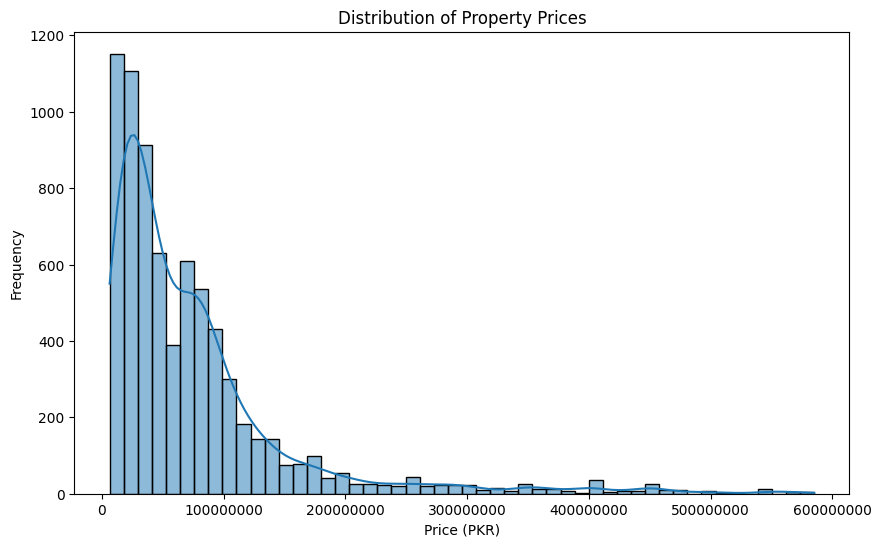

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, bins=50)
plt.title('Distribution of Property Prices')
plt.xlabel('Price (PKR)')
plt.ylabel('Frequency')
plt.ticklabel_format(style='plain', axis='x')
plt.show()

/tmp/ipykernel_5145/4186388286.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price_per_city.index, y=avg_price_per_city.values, palette='viridis')


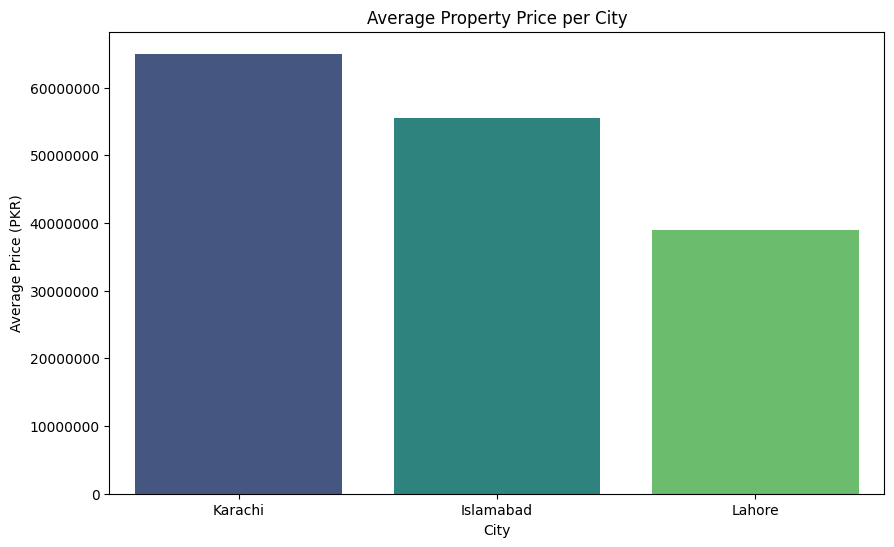

In [18]:
avg_price_per_city = df.groupby('city')['price'].median().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_price_per_city.index, y=avg_price_per_city.values, palette='viridis')
plt.title('Average Property Price per City')
plt.xlabel('City')
plt.ylabel('Average Price (PKR)')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

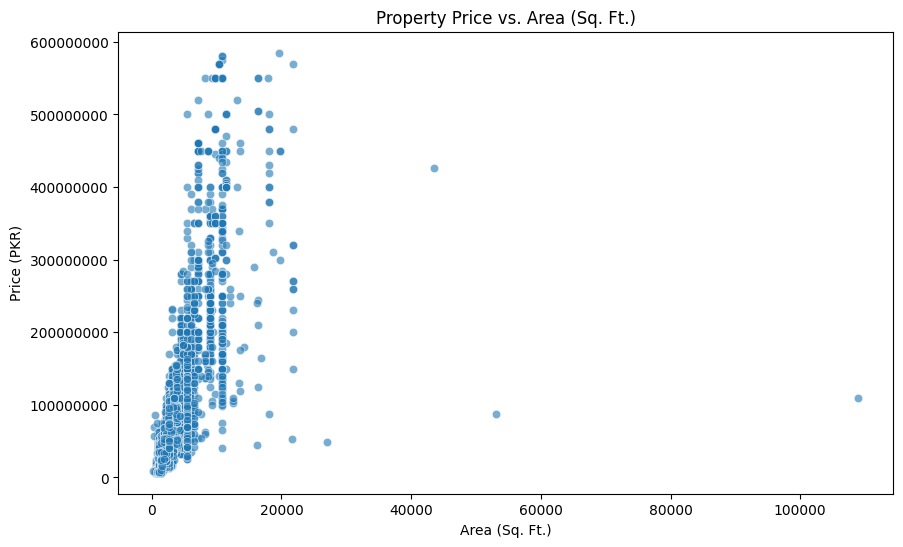

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='area_sqft', y='price', data=df, alpha=0.6)
plt.title('Property Price vs. Area (Sq. Ft.)')
plt.xlabel('Area (Sq. Ft.)')
plt.ylabel('Price (PKR)')
plt.ticklabel_format(style='plain', axis='x')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

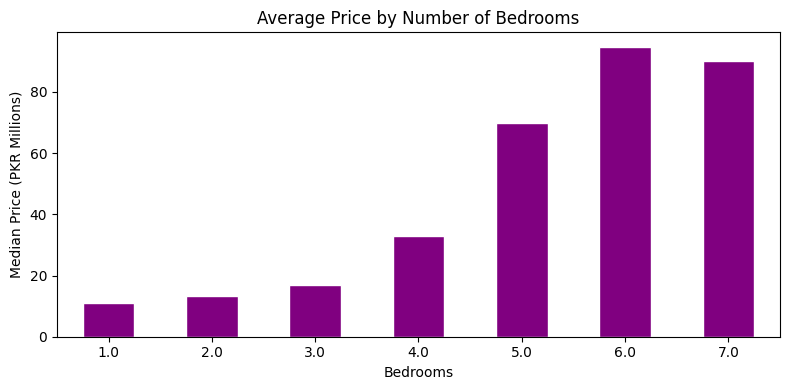

In [35]:

beds_price = df[df['beds'] <= 7].groupby('beds')['price'].median() / 1_000_000

plt.figure(figsize=(8, 4))
beds_price.plot(kind='bar', color='purple', edgecolor='white')
plt.title('Average Price by Number of Bedrooms')
plt.xlabel('Bedrooms')
plt.ylabel('Median Price (PKR Millions)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['city_code'] = le.fit_transform(df['city'])

print('City to number mapping (first 10):')
for city, code in zip(le.classes_[:10], range(10)):
    print(f'  {city} → {code}')

City to number mapping (first 10):
  Islamabad → 0
  Karachi → 1
  Lahore → 2


In [26]:

features = [
    'area_sqft',
    'baths',
    'beds',
    'city_code',
    'Kitchens',
    'Dining Room',
    'Drawing Room',
    'Laundry Room',
    'Store Rooms',
]

X = df[features]
y = df['price']

print('Input features shape:', X.shape)
print('Target shape         :', y.shape)

Input features shape: (7328, 9)
Target shape         : (7328,)


In [27]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f'Training samples : {len(X_train)}')
print(f'Testing  samples : {len(X_test)}')

Training samples : 5862
Testing  samples : 1466


In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

models = {
    'Linear Regression':   LinearRegression(),
    'Decision Tree':       DecisionTreeRegressor(max_depth=6, random_state=42),
    'Random Forest':       RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}

print(f'{"Model":<25}  {"R² Score":>10}  {"Avg Error (PKR M)":>18}')
print('-' * 60)

for name, model in models.items():
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    r2  = r2_score(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)

    results[name] = {'r2': r2, 'mae': mae, 'predictions': predictions}

    print(f'{name:<25}  {r2:>10.4f}  {mae/1_000_000:>18.2f}')

print()
print('R² Score: closer to 1.0 is better')
print('Avg Error: lower is better (in PKR Millions)')

Model                        R² Score   Avg Error (PKR M)
------------------------------------------------------------
Linear Regression              0.1720               27.47
Decision Tree                  0.7969               19.33
Random Forest                  0.7964               17.14
Gradient Boosting              0.8098               19.17

R² Score: closer to 1.0 is better
Avg Error: lower is better (in PKR Millions)


In [36]:
best_name = ""
best_r2 = 0

for name in results:
    if results[name]["r2"] > best_r2:
        best_r2 = results[name]["r2"]
        best_name = name

print("Best Model:", best_name)
print("R2 Score:", round(results[best_name]["r2"], 4))
print("Avg Error:", round(results[best_name]["mae"] / 1000000, 2), "Million PKR")

Best Model: Gradient Boosting
R2 Score: 0.8098
Avg Error: 19.17 Million PKR


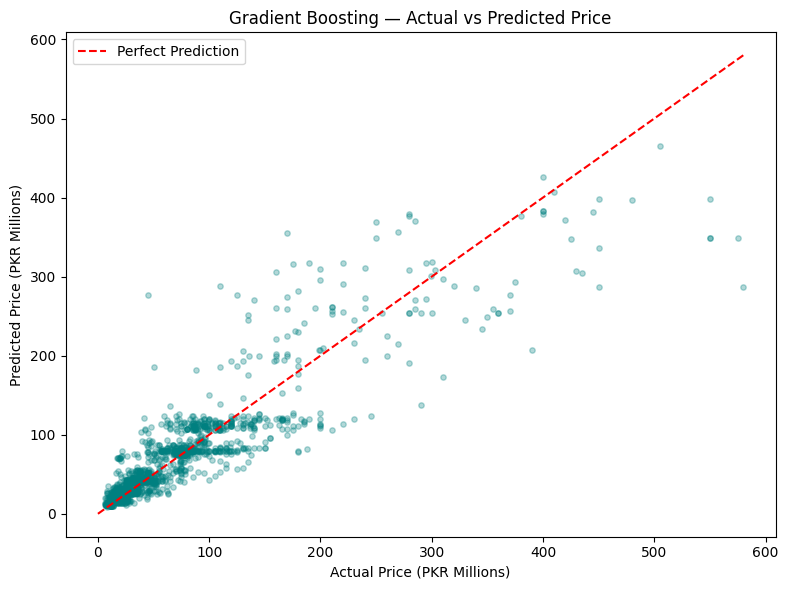

Points closer to the red line = better predictions!


In [37]:

actual = y_test.values / 1_000_000
predicted = best_preds / 1_000_000

plt.figure(figsize=(8, 6))
plt.scatter(actual, predicted, alpha=0.3, color='teal', s=15)

max_val = max(actual.max(), predicted.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect Prediction')

plt.title(f'{best_name} — Actual vs Predicted Price')
plt.xlabel('Actual Price (PKR Millions)')
plt.ylabel('Predicted Price (PKR Millions)')
plt.legend()
plt.tight_layout()
plt.show()

print('Points closer to the red line = better predictions!')

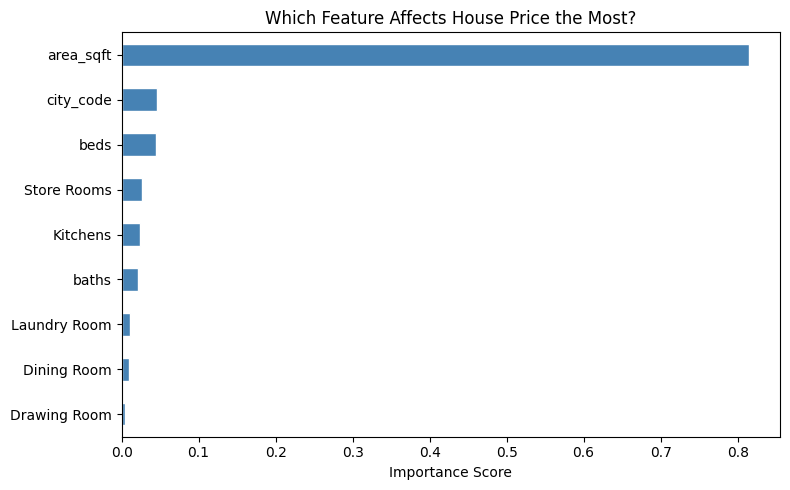

In [32]:


rf_model = models['Random Forest']
importance = pd.Series(rf_model.feature_importances_, index=features)
importance = importance.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importance.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Which Feature Affects House Price the Most?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [38]:
def predict_house_price(area_sqft, baths, beds, city_name,
                         kitchens=1, dining=0, drawing=0, laundry=0, store=0):
    """
    Predict the price of a house.

    area_sqft  : size of house in square feet
    baths      : number of bathrooms
    beds       : number of bedrooms
    city_name  : city name (e.g. 'Lahore', 'Islamabad')
    """
    if city_name in le.classes_:
        city_num = le.transform([city_name])[0]
    else:
        city_num = 0
        print(f'City "{city_name}" not in training data, using default.')

    house = pd.DataFrame([{
        'area_sqft':    area_sqft,
        'baths':        baths,
        'beds':         beds,
        'city_code':    city_num,
        'Kitchens':     kitchens,
        'Dining Room':  dining,
        'Drawing Room': drawing,
        'Laundry Room': laundry,
        'Store Rooms':  store,
    }])

    price = best_model.predict(house)[0]

    print(f'House Details:')
    print(f'  Area    : {area_sqft} sq ft')
    print(f'  Beds    : {beds}  |  Baths: {baths}')
    print(f'  City    : {city_name}')
    print()
    print(f'Predicted Price: PKR {price:,.0f}')

    if price >= 10_000_000:
        print(f'                = PKR {price/10_000_000:.2f} Crore')
    else:
        print(f'                = PKR {price/100_000:.1f} Lakh')

    return price


print('=== Example 1: Small house in Lahore ===')
predict_house_price(
    area_sqft = 272 * 5,
    baths     = 3,
    beds      = 3,
    city_name = 'Lahore'
)

=== Example 1: Small house in Lahore ===
House Details:
  Area    : 1360 sq ft
  Beds    : 3  |  Baths: 3
  City    : Lahore

Predicted Price: PKR 14,447,160
                = PKR 1.44 Crore


np.float64(14447159.582638161)

In [34]:
print('=== Example 2: Large house in Islamabad ===')
predict_house_price(
    area_sqft = 5445,
    baths     = 5,
    beds      = 5,
    city_name = 'Islamabad',
    dining    = 1,
    drawing   = 1,
    kitchens  = 2
)

=== Example 2: Large house in Islamabad ===
House Details:
  Area    : 5445 sq ft
  Beds    : 5  |  Baths: 5
  City    : Islamabad

Predicted Price: PKR 113,581,510
                = PKR 11.36 Crore


np.float64(113581509.63534774)

In [39]:
print('=== Example 3: Medium house in Karachi ===')
predict_house_price(
    area_sqft = 272 * 10,
    baths     = 4,
    beds      = 4,
    city_name = 'Karachi'
)

=== Example 3: Medium house in Karachi ===
House Details:
  Area    : 2720 sq ft
  Beds    : 4  |  Baths: 4
  City    : Karachi

Predicted Price: PKR 43,689,167
                = PKR 4.37 Crore


np.float64(43689166.98079844)